# Sentinel Data Exploration


In [1]:
from pystac import Collection, MediaType
from pystac_client import Client, CollectionClient

import xarray as xr
import dask.array as da
from dask.distributed import Client as DaskClient

In [10]:
polygon_geojson = {
    "type": "Polygon",
    "coordinates": [
        [
            [18.03, 49.63],
            [18.27, 49.42],
            [18.70, 49.33],
            [19.20, 49.30],
            [19.55, 49.35],
            [19.90, 49.32],
            [20.30, 49.30],
            [20.70, 49.25],
            [21.00, 49.30],
            [21.05, 49.45],
            [20.95, 49.70],
            [20.70, 49.85],
            [20.30, 49.90],
            [19.90, 49.90],
            [19.55, 49.87],
            [19.20, 49.85],
            [18.80, 49.78],
            [18.40, 49.75],
            [18.10, 49.75],
            [18.03, 49.63]
        ]
    ]
}


In [23]:
eopf_stac_api_root_endpoint = "https://stac.core.eopf.eodc.eu/"
collection = "sentinel-2-l2a"
eopf_catalog = Client.open(url=eopf_stac_api_root_endpoint)

search_result = eopf_catalog.search(
    collections=collection,
    intersects=polygon_geojson,
    datetime='2024-05-01T00:00:00Z/2025-05-31T23:59:59.999999Z',
    max_items=10
)
id_date_collection = [(item.id, item.datetime) for item in search_result.item_collection()]

id_date_collection

[('S2A_MSIL2A_20250531T100051_N0511_R122_T33UYR_20250531T120901',
  datetime.datetime(2025, 5, 31, 10, 0, 51, 24000, tzinfo=tzutc())),
 ('S2B_MSIL2A_20250531T095029_N0511_R079_T34UDV_20250531T120800',
  datetime.datetime(2025, 5, 31, 9, 50, 29, 24000, tzinfo=tzutc())),
 ('S2B_MSIL2A_20250531T095029_N0511_R079_T34UDA_20250531T120800',
  datetime.datetime(2025, 5, 31, 9, 50, 29, 24000, tzinfo=tzutc())),
 ('S2B_MSIL2A_20250531T095029_N0511_R079_T34UCV_20250531T120800',
  datetime.datetime(2025, 5, 31, 9, 50, 29, 24000, tzinfo=tzutc())),
 ('S2B_MSIL2A_20250531T095029_N0511_R079_T34UCA_20250531T120800',
  datetime.datetime(2025, 5, 31, 9, 50, 29, 24000, tzinfo=tzutc())),
 ('S2B_MSIL2A_20250531T095029_N0511_R079_T33UYR_20250531T120800',
  datetime.datetime(2025, 5, 31, 9, 50, 29, 24000, tzinfo=tzutc())),
 ('S2B_MSIL2A_20250531T095029_N0511_R079_T33UYQ_20250531T120800',
  datetime.datetime(2025, 5, 31, 9, 50, 29, 24000, tzinfo=tzutc())),
 ('S2C_MSIL2A_20250529T100051_N0511_R122_T33UYR_2025052

In [24]:
c_sentinel2 = eopf_catalog.get_collection(collection)
items = c_sentinel2.get_items(*[item[0] for item in id_date_collection])
assets = [item.get_assets(media_type=MediaType.ZARR) for item in items]
cloud_storage_urls = [asset['product'].href for asset in assets]
cloud_storage_urls

['https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202505-s02msil2a/31/products/cpm_v256/S2A_MSIL2A_20250531T100051_N0511_R122_T33UYR_20250531T120901.zarr',
 'https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202505-s02msil2a/31/products/cpm_v256/S2B_MSIL2A_20250531T095029_N0511_R079_T34UDV_20250531T120800.zarr',
 'https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202505-s02msil2a/31/products/cpm_v256/S2B_MSIL2A_20250531T095029_N0511_R079_T34UDA_20250531T120800.zarr',
 'https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202505-s02msil2a/31/products/cpm_v256/S2B_MSIL2A_20250531T095029_N0511_R079_T34UCV_20250531T120800.zarr',
 'https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202505-s02msil2a/31/products/cpm_v256/S2B_MSIL2A_20250531T095029_N0511_R079_T34UCA_20250531T120800.zarr',
 'https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202505-s02msil2a/31/products/cpm_v256/S2B_MSIL2A_20250531T095029_N0511_R079_T33UYR_20250531T

In [25]:
dt = xr.open_datatree(
    cloud_storage_urls[0],
    engine="zarr",
    chunks="auto"
)
dt

C:\Users\dmitr\AppData\Local\Temp\ipykernel_16620\4010089245.py:1: FutureWarning: In a future version, xarray will not decode the variable 'step' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  dt = xr.open_datatree(
C:\Users\dmitr\AppData\Local\Temp\ipykernel_16620\4010089245.py:1: FutureWarning: In a future version, xarray will not decode the variable 'step' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way o

<xarray.DataTree>
Group: /
│   Attributes:
│       other_metadata:  {'AOT_retrieval_model': 'SEN2COR_DDV', 'L0_ancillary_dat...
│       stac_discovery:  {'assets': {'analytic': {'eo:bands': [{'center_wavelengt...
├── Group: /conditions
│   ├── Group: /conditions/geometry
│   │       Dimensions:                        (angle: 2, band: 13, y: 23, x: 23,
│   │                                           detector: 2)
│   │       Coordinates:
│   │         * angle                          (angle) <U7 56B 'zenith' 'azimuth'
│   │         * band                           (band) <U3 156B 'b01' 'b02' ... 'b11' 'b12'
│   │         * y                              (y) int64 184B 5600040 5595040 ... 5490040
│   │         * x                              (x) int64 184B 699960 704960 ... 809960
│   │         * detector                       (detector) int64 16B 11 12
│   │       Data variables:
│   │           mean_sun_angles                (angle) float64 16B dask.array<chunksize=(2,), meta=np.ndarray>
│   │           mean_viewing_incidence_angles  (band, angle) float64 208B dask.array<chunksize=(13, 2), meta=np.ndarray>
│   │           sun_angles                     (angle, y, x) float64 8kB dask.array<chunksize=(2, 23, 23), meta=np.ndarray>
│   │           viewing_incidence_angles       (band, detector, angle, y, x) float64 220kB dask.array<chunksize=(13, 2, 2, 23, 23), meta=np.ndarray>
│   ├── Group: /conditions/mask
│   │   ├── Group: /conditions/mask/detector_footprint
│   │   │   ├── Group: /conditions/mask/detector_footprint/r10m
│   │   │   │       Dimensions:  (y: 10980, x: 10980)
│   │   │   │       Coordinates:
│   │   │   │         * y        (y) int64 88kB 5600035 5600025 5600015 ... 5490265 5490255 5490245
│   │   │   │         * x        (x) int64 88kB 699965 699975 699985 699995 ... 809735 809745 809755
│   │   │   │       Data variables:
│   │   │   │           b02      (y, x) uint8 121MB dask.array<chunksize=(10980, 10980), meta=np.ndarray>
│   │   │   │           b03      (y, x) uint8 121MB dask.array<chunksize=(10980, 10980), meta=np.ndarray>
│   │   │   │           b04      (y, x) uint8 121MB dask.array<chunksize=(10980, 10980), meta=np.ndarray>
│   │   │   │           b08      (y, x) uint8 121MB dask.array<chunksize=(10980, 10980), meta=np.ndarray>
│   │   │   ├── Group: /conditions/mask/detector_footprint/r20m
│   │   │   │       Dimensions:  (y: 5490, x: 5490)
│   │   │   │       Coordinates:
│   │   │   │         * y        (y) int64 44kB 5600030 5600010 5599990 ... 5490290 5490270 5490250
│   │   │   │         * x        (x) int64 44kB 699970 699990 700010 700030 ... 809710 809730 809750
│   │   │   │       Data variables:
│   │   │   │           b05      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   │           b06      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   │           b07      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   │           b11      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   │           b12      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   │           b8a      (y, x) uint8 30MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
│   │   │   └── Group: /conditions/mask/detector_footprint/r60m
│   │   │           Dimensions:  (y: 1830, x: 1830)
│   │   │           Coordinates:
│   │   │             * y        (y) int64 15kB 5600010 5599950 5599890 ... 5490390 5490330 5490270
│   │   │             * x        (x) int64 15kB 699990 700050 700110 700170 ... 809610 809670 809730
│   │   │           Data variables:
│   │   │               b01      (y, x) uint8 3MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
│   │   │               b09      (y, x) uint8 3MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
│   │   │               b10      (y, x) uint8 3MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
│   │   

In [26]:
ds = xr.open_zarr(
    cloud_storage_urls[0],
    chunks={},
    group="/measurements/reflectance/r20m",
    consolidated=True,
)
ds

<xarray.Dataset> Size: 2GB
Dimensions:  (y: 5490, x: 5490)
Coordinates:
  * y        (y) int64 44kB 5600030 5600010 5599990 ... 5490290 5490270 5490250
  * x        (x) int64 44kB 699970 699990 700010 700030 ... 809710 809730 809750
Data variables:
    b01      (y, x) float64 241MB dask.array<chunksize=(915, 915), meta=np.ndarray>
    b02      (y, x) float64 241MB dask.array<chunksize=(915, 915), meta=np.ndarray>
    b03      (y, x) float64 241MB dask.array<chunksize=(915, 915), meta=np.ndarray>
    b04      (y, x) float64 241MB dask.array<chunksize=(915, 915), meta=np.ndarray>
    b05      (y, x) float64 241MB dask.array<chunksize=(915, 915), meta=np.ndarray>
    b06      (y, x) float64 241MB dask.array<chunksize=(915, 915), meta=np.ndarray>
    b07      (y, x) float64 241MB dask.array<chunksize=(915, 915), meta=np.ndarray>
    b11      (y, x) float64 241MB dask.array<chunksize=(915, 915), meta=np.ndarray>
    b12      (y, x) float64 241MB dask.array<chunksize=(915, 915), meta=np.ndarray>
    b8a      (y, x) float64 241MB dask.array<chunksize=(915, 915), meta=np.ndarray>

In [27]:
ds = ds.assign_coords(time=id_date_collection[0][1])
ds

<xarray.Dataset> Size: 2GB
Dimensions:  (y: 5490, x: 5490)
Coordinates:
  * y        (y) int64 44kB 5600030 5600010 5599990 ... 5490290 5490270 5490250
  * x        (x) int64 44kB 699970 699990 700010 700030 ... 809710 809730 809750
    time     object 8B 2025-05-31T10:00:51.024000+00:00
Data variables:
    b01      (y, x) float64 241MB dask.array<chunksize=(915, 915), meta=np.ndarray>
    b02      (y, x) float64 241MB dask.array<chunksize=(915, 915), meta=np.ndarray>
    b03      (y, x) float64 241MB dask.array<chunksize=(915, 915), meta=np.ndarray>
    b04      (y, x) float64 241MB dask.array<chunksize=(915, 915), meta=np.ndarray>
    b05      (y, x) float64 241MB dask.array<chunksize=(915, 915), meta=np.ndarray>
    b06      (y, x) float64 241MB dask.array<chunksize=(915, 915), meta=np.ndarray>
    b07      (y, x) float64 241MB dask.array<chunksize=(915, 915), meta=np.ndarray>
    b11      (y, x) float64 241MB dask.array<chunksize=(915, 915), meta=np.ndarray>
    b12      (y, x) float64 241MB dask.array<chunksize=(915, 915), meta=np.ndarray>
    b8a      (y, x) float64 241MB dask.array<chunksize=(915, 915), meta=np.ndarray>

In [30]:
ndre = (ds['b8a'] - ds['b05']) / (ds['b8a'] + ds['b05'])
# reci = (ds['b07'] / ds['b05']) - 1
msi = (ds['b8a'] - ds['b11']) / (ds['b8a'] + ds['b11'])
ds['ndre'] = ndre
ds['msi'] = msi
ds

<xarray.Dataset> Size: 3GB
Dimensions:  (y: 5490, x: 5490)
Coordinates:
  * y        (y) int64 44kB 5600030 5600010 5599990 ... 5490290 5490270 5490250
  * x        (x) int64 44kB 699970 699990 700010 700030 ... 809710 809730 809750
    time     object 8B 2025-05-31T10:00:51.024000+00:00
Data variables:
    b01      (y, x) float64 241MB dask.array<chunksize=(915, 915), meta=np.ndarray>
    b02      (y, x) float64 241MB dask.array<chunksize=(915, 915), meta=np.ndarray>
    b03      (y, x) float64 241MB dask.array<chunksize=(915, 915), meta=np.ndarray>
    b04      (y, x) float64 241MB dask.array<chunksize=(915, 915), meta=np.ndarray>
    b05      (y, x) float64 241MB dask.array<chunksize=(915, 915), meta=np.ndarray>
    b06      (y, x) float64 241MB dask.array<chunksize=(915, 915), meta=np.ndarray>
    b07      (y, x) float64 241MB dask.array<chunksize=(915, 915), meta=np.ndarray>
    b11      (y, x) float64 241MB dask.array<chunksize=(915, 915), meta=np.ndarray>
    b12      (y, x) float64 241MB dask.array<chunksize=(915, 915), meta=np.ndarray>
    b8a      (y, x) float64 241MB dask.array<chunksize=(915, 915), meta=np.ndarray>
    ndre     (y, x) float64 241MB dask.array<chunksize=(915, 915), meta=np.ndarray>
    msi      (y, x) float64 241MB dask.array<chunksize=(915, 915), meta=np.ndarray>

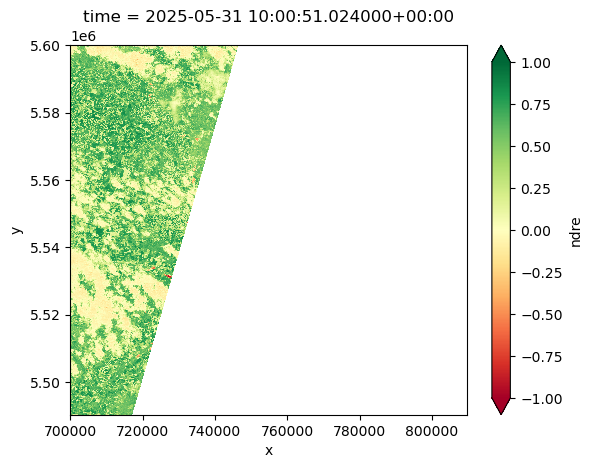

In [31]:
ds['ndre'].plot.imshow(vmin=-1, vmax=1, cmap='RdYlGn')

In [34]:
datasets = []
for path in cloud_storage_urls:
    ds = xr.open_zarr(path, chunks='auto',
                      group="/measurements/reflectance/r20m",
                      consolidated=True)
    t = [next(item[1] for item in id_date_collection if item[0] in path)]
    ds = ds.assign_coords(time=t)
    datasets.append(ds)

combined = xr.concat(datasets, dim="time", join="outer")
combined

C:\Users\dmitr\miniconda3\envs\climate_analysis\Lib\site-packages\dask\array\core.py:5061: PerformanceWarning: Increasing number of chunks by factor of 12
  result = blockwise(
C:\Users\dmitr\miniconda3\envs\climate_analysis\Lib\site-packages\dask\array\core.py:5061: PerformanceWarning: Increasing number of chunks by factor of 12
  result = blockwise(
C:\Users\dmitr\miniconda3\envs\climate_analysis\Lib\site-packages\dask\array\core.py:5061: PerformanceWarning: Increasing number of chunks by factor of 12
  result = blockwise(
C:\Users\dmitr\miniconda3\envs\climate_analysis\Lib\site-packages\dask\array\core.py:5061: PerformanceWarning: Increasing number of chunks by factor of 12
  result = blockwise(
C:\Users\dmitr\miniconda3\envs\climate_analysis\Lib\site-packages\dask\array\core.py:5061: PerformanceWarning: Increasing number of chunks by factor of 12
  result = blockwise(
C:\Users\dmitr\miniconda3\envs\climate_analysis\Lib\site-packages\dask\array\core.py:5061: PerformanceWarning: Incr

<xarray.Dataset> Size: 134GB
Dimensions:  (time: 10, y: 10491, x: 15978)
Coordinates:
  * time     (time) object 80B 2025-05-31 10:00:51.024000+00:00 ... 2025-05-2...
  * y        (y) int64 84kB 5390230 5390250 5390270 ... 5599990 5600010 5600030
  * x        (x) int64 128kB 300010 300030 300050 ... 809710 809730 809750
Data variables:
    b01      (time, y, x) float64 13GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b02      (time, y, x) float64 13GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b03      (time, y, x) float64 13GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b04      (time, y, x) float64 13GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b05      (time, y, x) float64 13GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b06      (time, y, x) float64 13GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b07      (time, y, x) float64 13GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b11      (time, y, x) float64 13GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b12      (time, y, x) float64 13GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b8a      (time, y, x) float64 13GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>

In [35]:
ndre = (combined['b8a'] - combined['b05']) / (combined['b8a'] + combined['b05'])
# reci = (combined['b07'] / combined['b05']) - 1
msi = (combined['b8a'] - combined['b11']) / (combined['b8a'] + combined['b11'])
combined['ndre'] = ndre
combined['msi'] = msi
combined

<xarray.Dataset> Size: 161GB
Dimensions:  (time: 10, y: 10491, x: 15978)
Coordinates:
  * time     (time) object 80B 2025-05-31 10:00:51.024000+00:00 ... 2025-05-2...
  * y        (y) int64 84kB 5390230 5390250 5390270 ... 5599990 5600010 5600030
  * x        (x) int64 128kB 300010 300030 300050 ... 809710 809730 809750
Data variables:
    b01      (time, y, x) float64 13GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b02      (time, y, x) float64 13GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b03      (time, y, x) float64 13GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b04      (time, y, x) float64 13GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b05      (time, y, x) float64 13GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b06      (time, y, x) float64 13GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b07      (time, y, x) float64 13GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b11      (time, y, x) float64 13GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b12      (time, y, x) float64 13GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b8a      (time, y, x) float64 13GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    ndre     (time, y, x) float64 13GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    msi      (time, y, x) float64 13GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>

In [37]:
combined['ndre_z'] = (combined['ndre'] - combined['ndre'].mean(dim='time')) / combined['ndre'].std(dim='time')
combined

<xarray.Dataset> Size: 188GB
Dimensions:    (time: 10, y: 10491, x: 15978)
Coordinates:
  * time       (time) object 80B 2025-05-31 10:00:51.024000+00:00 ... 2025-05...
  * y          (y) int64 84kB 5390230 5390250 5390270 ... 5600010 5600030
  * x          (x) int64 128kB 300010 300030 300050 ... 809710 809730 809750
Data variables: (12/14)
    b01        (time, y, x) float64 13GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b02        (time, y, x) float64 13GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b03        (time, y, x) float64 13GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b04        (time, y, x) float64 13GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b05        (time, y, x) float64 13GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b06        (time, y, x) float64 13GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    ...         ...
    b12        (time, y, x) float64 13GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b8a        (time, y, x) float64 13GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    ndre       (time, y, x) float64 13GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    msi        (time, y, x) float64 13GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    ndre_mean  (time, y, x) float64 13GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    ndre_z     (time, y, x) float64 13GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>

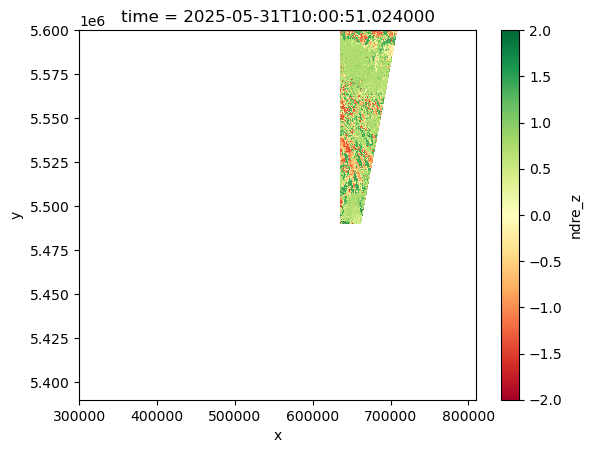

In [40]:
combined['ndre_z'].isel(time=0).plot.imshow(vmin=-2, vmax=2, cmap='RdYlGn')